# Setup

## Imports and Installs

In [3]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape

### Imports

In [4]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

## Parameters

In [5]:
state_name = "Ohio"
city_name = "Columbus"
mini = True
# mini = False

In [6]:
dist_threshold = 10  # Only take edges with dist <= 10 km, 5 km for big

## Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [7]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


## Assign Data directory path

In [8]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"
umst_dir = data_dir + "/UMST Graph/graphs"

In [9]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Files in directory :  ['Census Data', 'Images', 'Hotspot Data', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'UMST Graph', 'gh_cache', 'Deliveries', 'avg_hotspot_data.json', 'Results']


# Finding Hotspot Locations
Based on the analysis, the hotspot location is chosen as center (mean) of the location within the tract. We first store these locations in a seperate `.geojson` file

In [10]:
from shapely import distance as shapely_distance

with open(data_dir + "/Census Data/census_tract_wise_locations.json", 'r') as f:
  data = json.load(f)

tract_id = list()
hotspot_geometry = list()
num_locations = list()

for census_tract in data:
  lat = []
  lon = []
  for point in data[census_tract]:
    lat.append(point["lat"])
    lon.append(point["lon"])


  lat = pd.Series(lat)
  lon = pd.Series(lon)
  hotspot_lat = lat.mean()
  hotspot_lon = lon.mean()

  tract_id.append(census_tract)
  hotspot_geometry.append(Point(hotspot_lon,hotspot_lat))
  num_locations.append(len(data[census_tract]))



#Adds hotspots to empty tracts
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")


for index, row in census_df.iterrows():
    GEOID = row['GEOID']
    if GEOID not in tract_id:
        centroid = row['geometry'].centroid
        tract_id.append(GEOID)
        hotspot_geometry.append(centroid)
        num_locations.append(0)



try:
  os.mkdir(data_dir + "/Hotspot Data/")
except:
  print(data_dir + "/Hotspot Data/" + " Already Exists")

tract_gdf = gpd.GeoDataFrame({'GEOID': tract_id, 'geometry': hotspot_geometry, 'locations': num_locations}, crs='EPSG:4326')

# IMPORTANT: This line of code below is added to remove an youtlier hotspot that appear far outside city bounds. This issue happened when generating hotspots for LA
#   This is a temporary fix. One of the hotspots generates in the wrong spot, and this removes it.
tract_gdf = tract_gdf[shapely_distance(tract_gdf['geometry'], tract_gdf.unary_union.centroid) <= 5]

tract_gdf.to_file(data_dir + '/Hotspot Data/hotspot_data.geojson', driver='GeoJSON')

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Hotspot Data/ Already Exists


/tmp/ipykernel_1648/3150391740.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  tract_gdf = tract_gdf[shapely_distance(tract_gdf['geometry'], tract_gdf.unary_union.centroid) <= 5]


Plotting the hotspot locations

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


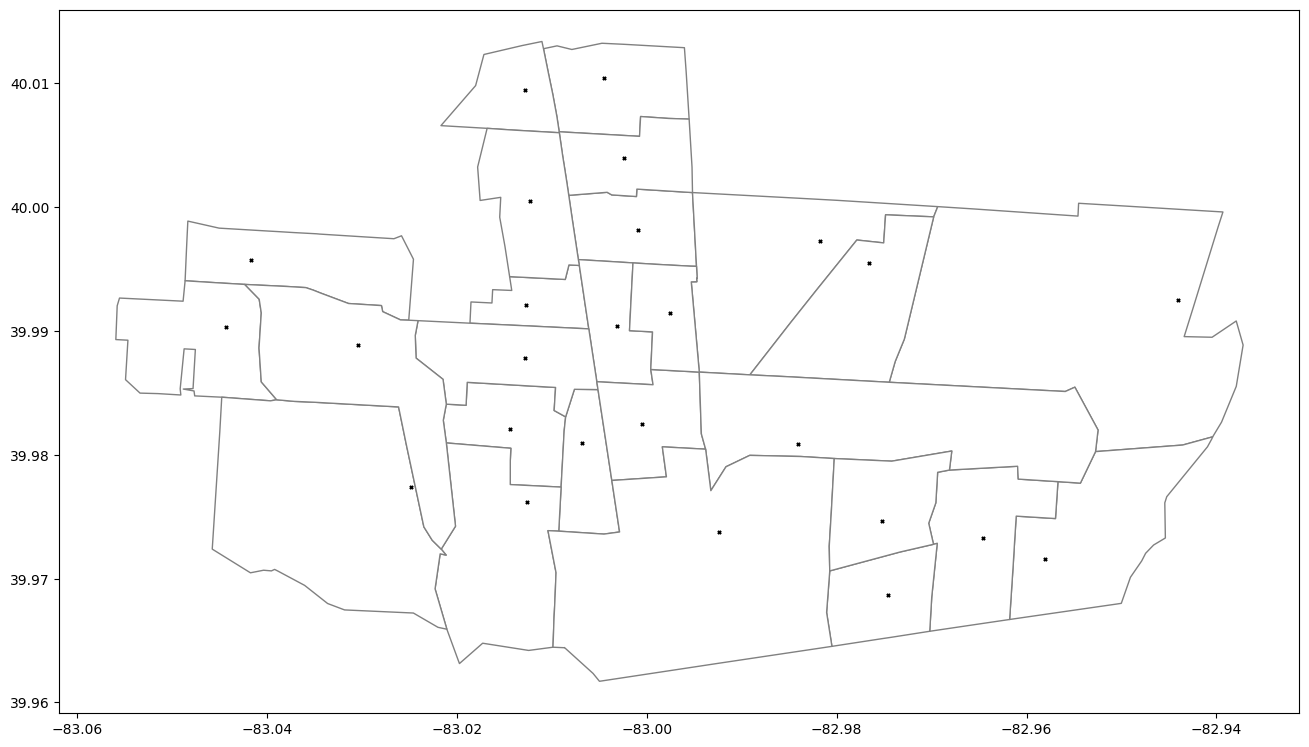

In [11]:
census_dir = data_dir + "/Census Data/census_tract_data.geojson"
census_df = gpd.read_file(census_dir, crs='EPSG:4326')

hotspot_dir = data_dir + "/Hotspot Data/hotspot_data.geojson"
hotspot_locations = gpd.read_file(hotspot_dir, crs='EPSG:4326')

tract = gpd.GeoSeries(census_df.loc[:].geometry)
size = (16,16)
base = tract.plot(color="white", edgecolor="gray", figsize=size)
hotspot_locations.plot(ax = base, marker='x', color='black', markersize=5, figsize=size)

# save_image(plt, 'city_base')
plt.show()

# **Graph Generation**

In [12]:
import networkx as nx
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd

def create_hotspot_graph(hotspot_locations, connection_threshold_km=None, connect_all=False):
    """
    Create a graph from hotspot locations where each hotspot is a node.

    Parameters:
    - hotspot_locations: GeoDataFrame with hotspot data
    - connection_threshold_km: Maximum distance in km to connect nodes (if None, connects all)
    - connect_all: If True, creates a complete graph with all nodes connected

    Returns:
    - NetworkX graph object
    """

    # Create an empty graph
    G = nx.Graph()

    # Add nodes for each hotspot
    for idx, row in hotspot_locations.iterrows():
        geoid = row['GEOID']
        geometry = row['geometry']
        locations = row['locations']

        # Extract coordinates
        lat = geometry.y
        lon = geometry.x

        # Add node with attributes
        G.add_node(geoid,
                  lat=lat,
                  lon=lon,
                  locations=locations,
                  coordinates=(lat, lon),
                  geometry=geometry)

    # Add edges based on distance
    nodes = list(G.nodes())

    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            node1, node2 = nodes[i], nodes[j]

            # Get coordinates
            coord1 = G.nodes[node1]['coordinates']
            coord2 = G.nodes[node2]['coordinates']

            # Calculate distance using geodesic (great circle distance)
            distance_km = geodesic(coord1, coord2).kilometers

            # Add edge based on criteria
            should_connect = False

            if connect_all:
                should_connect = True
            elif connection_threshold_km is not None:
                should_connect = distance_km <= connection_threshold_km
            else:
                # Default: connect all nodes for complete graph (useful for MST)
                should_connect = True

            if should_connect:
                G.add_edge(node1, node2, weight=distance_km, distance=distance_km)


    return G

def visualize_hotspot_graph(G, hotspot_locations, census_df=None, show_edges=True, edge_alpha=0.3):
    """
    Visualize the hotspot graph on a map.

    Parameters:
    - G: NetworkX graph
    - hotspot_locations: GeoDataFrame with hotspot data
    - show_edges: Whether to show graph edges
    - edge_alpha: Transparency of edges
    """

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Plot census tract boundaries first (as base layer)
    if census_df is not None:
        census_df.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.5, alpha=0.8)

    # Plot hotspots
    hotspot_locations.plot(ax=ax, marker='o', color='red', markersize=50, alpha=0.7, label='Hotspots')

    if show_edges and G.number_of_edges() > 0:
        # Draw edges
        for edge in G.edges():
            node1, node2 = edge
            lat1, lon1 = G.nodes[node1]['coordinates']
            lat2, lon2 = G.nodes[node2]['coordinates']

            ax.plot([lon1, lon2], [lat1, lat2], 'b-', alpha=edge_alpha, linewidth=0.5)

    # Add labels for nodes with location counts
    for node in G.nodes():
        lat, lon = G.nodes[node]['coordinates']
        locations = G.nodes[node]['locations']
        ax.annotate(f'{locations}', (lon, lat), xytext=(3, 3), textcoords='offset points',
                   fontsize=8, alpha=0.8)

    ax.set_title(f'Hotspot Graph\nNodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_graph_statistics(G):
    """
    Print basic statistics about the graph.
    """
    print("=== Graph Statistics ===")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Graph density: {nx.density(G):.4f}")
    print(f"Is connected: {nx.is_connected(G)}")

    if G.number_of_edges() > 0:
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        print(f"Average edge weight (distance): {np.mean(weights):.2f} km")
        print(f"Min edge weight: {np.min(weights):.2f} km")
        print(f"Max edge weight: {np.max(weights):.2f} km")

    if not nx.is_connected(G):
        components = list(nx.connected_components(G))
        print(f"Number of connected components: {len(components)}")
        component_sizes = [len(comp) for comp in components]
        print(f"Component sizes: {component_sizes}")


## Graph Creation function call

Creating complete hotspot graph (all nodes connected)...
=== Graph Statistics ===
Number of nodes: 26
Number of edges: 325
Graph density: 1.0000
Is connected: True
Average edge weight (distance): 3.08 km
Min edge weight: 0.48 km
Max edge weight: 8.57 km

Visualizing hotspot graph with census tract boundaries...


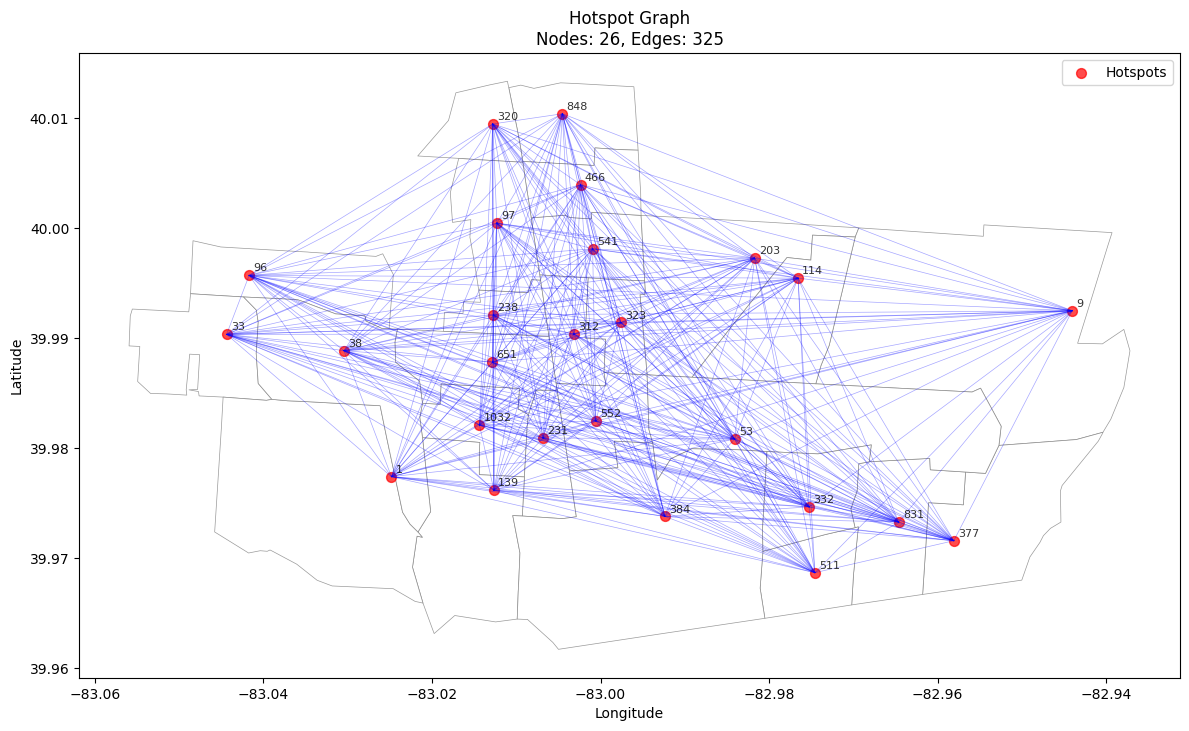

In [13]:
# Create the graph from your hotspot data
print("Creating complete hotspot graph (all nodes connected)...")
hotspot_graph = create_hotspot_graph(hotspot_locations,connection_threshold_km=dist_threshold)

# Display graph statistics
get_graph_statistics(hotspot_graph)

# Visualize the graph with census tract boundaries
print("\nVisualizing hotspot graph with census tract boundaries...")
visualize_hotspot_graph(hotspot_graph, hotspot_locations, census_df, show_edges=True, edge_alpha=0.35)



# GH-Query



In [14]:
import requests
import time
import pickle
import os
import hashlib
from typing import List, Dict, Tuple, Any
import networkx as nx

# Configuration
CACHE_DIR = os.path.join(data_dir, "gh_cache")
CACHE_FILE = os.path.join(CACHE_DIR, "gh_queries.pkl")

keys = [
    'd927fb04-31ab-43e6-9b4b-62a11d96e928',  # Add your GraphHopper API key here
    '70ec22eb-155c-41b7-9daf-e760e8ac34a8'
]

URL = "https://graphhopper.com/api/1/matrix"
req_lim = 80
key_ind = len(keys) - 1

In [15]:
def gh_query(from_point: List[float], to_point: List[float], keys: List[str]) -> Dict:
    """
    GraphHopper query function with caching
    """
    global key_ind

    # Check cache first
    cache = load_cache()
    cache_key = generate_cache_key(from_point, to_point)

    if cache_key in cache:
        print(f"Cache hit for {from_point} -> {to_point}")
        return cache[cache_key]

    print(f"Querying API for {from_point} -> {to_point}")

    # Do-while loop in python, runs query before checking
    while True:
        # Query to provide the key
        query = {"key": keys[key_ind]}
        # Payload to send rest of data
        payload = {
            "profile": "car",
            "from_points": from_point,
            "to_points": to_point,
            "out_arrays": ["distances", "times", "weights"],
            "fail_fast": "true",
        }
        # Get response using POST
        response = requests.post(URL, json=payload, params=query)

        # Check if response is successful
        if response.status_code != 200:
            print(f"HTTP Error {response.status_code}: {response.text}")
            time.sleep(1)
            continue

        try:
            data = response.json()  # Store data as json
        except requests.exceptions.JSONDecodeError as e:
            print(f"JSON decode error: {e}")
            print(f"Response content: {response.text[:500]}")  # First 500 chars
            time.sleep(1)
            continue

        # If there is a message, then something went wrong.
        if 'message' not in data.keys():
            # Cache successful result
            cache[cache_key] = data
            save_cache(cache)
            return data  # No message so return data
        else:  # Assume message says key ran out
            if key_ind > 0:  # Make sure we don't exit bounds of list
                key_ind -= 1
            else:  # Otherwise we have run out of keys
                if 'Minutely API limit heavily violated' not in data['message']:
                    print(data['message'])
                key_ind = len(keys) - 1
                time.sleep(60)  # Wait if rate limited

## Utility functions for Graphhopper query

In [16]:
def ensure_cache_dir():
    """Create cache directory if it doesn't exist"""
    if not os.path.exists(CACHE_DIR):
        os.makedirs(CACHE_DIR)

def load_cache() -> Dict:
    """Load cached queries from disk"""
    if os.path.exists(CACHE_FILE):
        try:
            with open(CACHE_FILE, 'rb') as f:
                return pickle.load(f)
        except:
            return {}
    return {}

def save_cache(cache: Dict):
    """Save cached queries to disk"""
    ensure_cache_dir()
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)

def generate_cache_key(from_point: List[float], to_point: List[float], profile: str = "car") -> str:
    """Generate unique cache key for query"""
    # Handle both single coordinate pairs and lists of coordinates
    if isinstance(from_point[0], list):
        # If it's a list of lists, take the first coordinate pair
        from_coords = from_point[0]
        to_coords = to_point[0]
    else:
        # If it's a single coordinate pair
        from_coords = from_point
        to_coords = to_point

    key_data = f"{from_coords[0]:.6f},{from_coords[1]:.6f}_{to_coords[0]:.6f},{to_coords[1]:.6f}_{profile}"
    return hashlib.md5(key_data.encode()).hexdigest()

def run_graphhopper_queries(hotspot_graph: nx.Graph, keys: List[str]) -> nx.Graph:
    """
    Run GraphHopper queries for all edges in the graph and update with real data
    """
    print(f"Starting GraphHopper queries for {len(hotspot_graph.edges())} edges...")

    # Create a copy of the graph to avoid modifying the original
    updated_graph = hotspot_graph.copy()

    # Counter for progress tracking
    total_edges = len(hotspot_graph.edges())
    processed = 0

    # Process each edge
    for u, v, data in hotspot_graph.edges(data=True):
        processed += 1
        print(f"Processing edge {processed}/{total_edges}: {u} -> {v}")

        # Get coordinates from node data (handle different longitude key names)
        u_node = hotspot_graph.nodes[u]
        v_node = hotspot_graph.nodes[v]

        # Try different longitude key variations
        lng_key = None
        for key in ['lng', 'lon', 'longitude']:
            if key in u_node:
                lng_key = key
                break

        if lng_key is None:
            print(f"  Error: No longitude key found in node {u}. Available keys: {list(u_node.keys())}")
            continue

        from_coords = [[u_node[lng_key], u_node['lat']]]  # [lon, lat] format as list of lists
        to_coords = [[v_node[lng_key], v_node['lat']]]    # [lon, lat] format as list of lists

        try:
            # Query GraphHopper
            result = gh_query(from_coords, to_coords, keys)

            # Extract distance and time from result
            if 'distances' in result and 'times' in result:
                # GraphHopper returns matrices, we need [0][0] for single point-to-point
                distance_m = result['distances'][0][0]  # Distance in meters
                time_s = result['times'][0][0]  # Time in seconds

                # Convert to desired units
                distance_km = distance_m / 1000.0  # Convert to kilometers
                time_minutes = time_s / 60.0  # Convert to minutes

                # Update edge data
                updated_graph[u][v]['distance'] = distance_km
                updated_graph[u][v]['time'] = time_minutes

                print(f"  Distance: {distance_km:.2f} km, Time: {time_minutes:.2f} min")
            else:
                print(f"  Warning: No valid data returned for edge {u} -> {v}")
                # Keep original values if query failed

        except Exception as e:
            print(f"  Error processing edge {u} -> {v}: {str(e)}")
            # Keep original values if query failed

        # Small delay to be respectful to the API
        time.sleep(0.1)

    print(f"\nCompleted GraphHopper queries for all {total_edges} edges!")
    return updated_graph

def get_cache_stats():
    """Get statistics about cached queries"""
    cache = load_cache()
    print(f"Cache contains {len(cache)} queries")
    return len(cache)

def clear_cache():
    """Clear all cached queries"""
    if os.path.exists(CACHE_FILE):
        os.remove(CACHE_FILE)
        print("Cache cleared!")
    else:
        print("No cache file found.")

In [17]:
get_cache_stats()

print("GraphHopper Query Manager ready!")
print("Usage:")
print("1. updated_graph = run_graphhopper_queries(hotspot_graph, keys)")
print("2. get_cache_stats() - to see cached queries")
print("3. clear_cache() - to clear all cached data")

Cache contains 325 queries
GraphHopper Query Manager ready!
Usage:
1. updated_graph = run_graphhopper_queries(hotspot_graph, keys)
2. get_cache_stats() - to see cached queries
3. clear_cache() - to clear all cached data


In [18]:
gh_hotspot_graph = run_graphhopper_queries(hotspot_graph, keys)

Starting GraphHopper queries for 325 edges...
Processing edge 1/325: 39049001110 -> 39049003000
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-82.99236835151807, 39.973786476294]]
  Distance: 6.11 km, Time: 10.08 min
Processing edge 2/325: 39049001110 -> 39049001121
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.01230072161665, 40.00045262230653]]
  Distance: 1.71 km, Time: 3.90 min
Processing edge 3/325: 39049001110 -> 39049007830
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.04169910684054, 39.99570169804188]]
  Distance: 3.96 km, Time: 9.45 min
Processing edge 4/325: 39049001110 -> 39049002200
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.00055377317632, 39.982470204529754]]
  Distance: 3.85 km, Time: 6.37 min
Processing edge 5/325: 39049001110 -> 39049001200
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.00236893225473, 40.00394748402827]]
  Distance: 1.93 km, Time: 4.30 min
Processing edge 6/325: 3

In [19]:
import pickle
import os

# Define directory and file path
save_dir = os.path.join(data_dir, "UMST Graph")
os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

file_path = os.path.join(save_dir, "gh_hotspot_graph.pkl")

# Save pickle file
with open(file_path, "wb") as f:
    pickle.dump(gh_hotspot_graph, f)


In [20]:
def prepare_graph_for_graphml(G):
      """Remove or convert attributes that GraphML cannot handle"""
      G_clean = G.copy()

      # Convert tuple coordinates to separate lat/lon attributes
      for node in G_clean.nodes():
          if 'coordinates' in G_clean.nodes[node]:
              lat, lon = G_clean.nodes[node]['coordinates']
              G_clean.nodes[node]['lat'] = float(lat)
              G_clean.nodes[node]['lon'] = float(lon)
              del G_clean.nodes[node]['coordinates']

          # Remove geometry objects (Shapely objects not supported)
          if 'geometry' in G_clean.nodes[node]:
              del G_clean.nodes[node]['geometry']

      return G_clean

In [21]:
# Save original graph-> hotspot graph
hotspot_clean = prepare_graph_for_graphml(gh_hotspot_graph)
nx.write_graphml(hotspot_clean, umst_dir + "/gh_hotspot_graph.graphml")
print(f"Full Graph saved to: {umst_dir}/gh_hotspot_graph.graphml")

Full Graph saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/gh_hotspot_graph.graphml


# This part is just for analysis. Skip!! (May delete later)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

def compare_graphs(geodesic_graph, gh_graph, save_results=True):
    """
    Compare geodesic_hotspot_graph with GraphHopper-updated gh_hotspot_graph

    Args:
        geodesic_graph: geodesic hotspot graph
        gh_graph: GraphHopper updated graph
        save_results: Whether to save comparison results to CSV

    Returns:
        Dictionary with comparison statistics
    """

    print("=== GRAPH COMPARISON ANALYSIS ===\n")

    # Basic graph info
    print(f"Geodesic Graph: {len(geodesic_graph.nodes())} nodes, {len(geodesic_graph.edges())} edges")
    print(f"GH Graph: {len(gh_graph.nodes())} nodes, {len(gh_graph.edges())} edges")
    print()

    # Collect comparison data
    comparison_data = []

    for u, v, geodesic_data in geodesic_graph.edges(data=True):
        if gh_graph.has_edge(u, v):
            gh_data = gh_graph[u][v]

            # Extract geodesic values
            geodesic_distance = geodesic_data.get('distance', 0)
            geodesic_time = geodesic_data.get('time', 0)

            # Extract GraphHopper values
            gh_distance = gh_data.get('distance', 0)
            gh_time = gh_data.get('time', 0)

            # Calculate differences
            distance_diff = gh_distance - geodesic_distance
            time_diff = gh_time - geodesic_time

            # Calculate percentage changes (avoid division by zero)
            distance_pct_change = (distance_diff / geodesic_distance * 100) if geodesic_distance != 0 else 0
            time_pct_change = (time_diff / geodesic_time * 100) if geodesic_time != 0 else 0

            comparison_data.append({
                'edge': f"{u}->{v}",
                'geodesic_distance_km': geodesic_distance,
                'gh_distance_km': gh_distance,
                'distance_diff_km': distance_diff,
                'distance_pct_change': distance_pct_change,
                'geodesic_time_min': geodesic_time,
                'gh_time_min': gh_time,
                'time_diff_min': time_diff,
                'time_pct_change': time_pct_change
            })

    # Convert to DataFrame for easier analysis
    df = pd.DataFrame(comparison_data)

    if len(df) == 0:
        print("No matching edges found between graphs!")
        return {}

    # DISTANCE ANALYSIS
    print("=== DISTANCE COMPARISON ===")
    print(f"Geodesic Distance - Mean: {df['geodesic_distance_km'].mean():.2f} km, Std: {df['geodesic_distance_km'].std():.2f} km")
    print(f"GH Distance - Mean: {df['gh_distance_km'].mean():.2f} km, Std: {df['gh_distance_km'].std():.2f} km")
    print(f"Distance Difference - Mean: {df['distance_diff_km'].mean():.2f} km, Std: {df['distance_diff_km'].std():.2f} km")
    print(f"Distance % Change - Mean: {df['distance_pct_change'].mean():.1f}%, Std: {df['distance_pct_change'].std():.1f}%")
    print(f"Distance Range: {df['distance_diff_km'].min():.2f} to {df['distance_diff_km'].max():.2f} km")
    print()

    # TIME ANALYSIS
    print("=== TIME COMPARISON ===")
    print(f"Geodesic Time - Mean: {df['geodesic_time_min'].mean():.2f} min, Std: {df['geodesic_time_min'].std():.2f} min")
    print(f"GH Time - Mean: {df['gh_time_min'].mean():.2f} min, Std: {df['gh_time_min'].std():.2f} min")
    print(f"Time Difference - Mean: {df['time_diff_min'].mean():.2f} min, Std: {df['time_diff_min'].std():.2f} min")
    print(f"Time % Change - Mean: {df['time_pct_change'].mean():.1f}%, Std: {df['time_pct_change'].std():.1f}%")
    print(f"Time Range: {df['time_diff_min'].min():.2f} to {df['time_diff_min'].max():.2f} min")
    print()

    # TOP CHANGES
    print("=== LARGEST CHANGES ===")

    # Top 10 distance increases
    top_dist_increases = df.nlargest(10, 'distance_diff_km')[['edge', 'geodesic_distance_km', 'gh_distance_km', 'distance_diff_km', 'distance_pct_change']]
    print("\nTop 10 Distance Increases:")
    print(top_dist_increases.to_string(index=False))

    # Top 10 time increases
    top_time_increases = df.nlargest(10, 'time_diff_min')[['edge', 'geodesic_time_min', 'gh_time_min', 'time_diff_min', 'time_pct_change']]
    print("\nTop 10 Time Increases:")
    print(top_time_increases.to_string(index=False))

    # DISTRIBUTION ANALYSIS
    print("\n=== DISTRIBUTION ANALYSIS ===")

    # Distance categories
    dist_pos = len(df[df['distance_diff_km'] > 0])
    dist_neg = len(df[df['distance_diff_km'] < 0])
    dist_same = len(df[df['distance_diff_km'] == 0])

    print(f"Distance Changes: {dist_pos} increased, {dist_neg} decreased, {dist_same} unchanged")

    # Time categories
    time_pos = len(df[df['time_diff_min'] > 0])
    time_neg = len(df[df['time_diff_min'] < 0])
    time_same = len(df[df['time_diff_min'] == 0])

    print(f"Time Changes: {time_pos} increased, {time_neg} decreased, {time_same} unchanged")

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Graph Comparison: Geodesic vs GraphHopper Data', fontsize=16)

    # Distance comparison scatter plot
    axes[0,0].scatter(df['geodesic_distance_km'], df['gh_distance_km'], alpha=0.6)
    axes[0,0].plot([df['geodesic_distance_km'].min(), df['geodesic_distance_km'].max()],
                   [df['geodesic_distance_km'].min(), df['geodesic_distance_km'].max()], 'r--', alpha=0.8)
    axes[0,0].set_xlabel('Geodesic Distance (km)')
    axes[0,0].set_ylabel('GraphHopper Distance (km)')
    axes[0,0].set_title('Distance Comparison')
    axes[0,0].grid(True, alpha=0.3)

    # Time comparison scatter plot
    axes[0,1].scatter(df['geodesic_time_min'], df['gh_time_min'], alpha=0.6)
    axes[0,1].plot([df['geodesic_time_min'].min(), df['geodesic_time_min'].max()],
                   [df['geodesic_time_min'].min(), df['geodesic_time_min'].max()], 'r--', alpha=0.8)
    axes[0,1].set_xlabel('Geodesic Time (min)')
    axes[0,1].set_ylabel('GraphHopper Time (min)')
    axes[0,1].set_title('Time Comparison')
    axes[0,1].grid(True, alpha=0.3)

    # Distance difference histogram
    axes[1,0].hist(df['distance_diff_km'], bins=30, alpha=0.7, edgecolor='black')
    axes[1,0].axvline(0, color='red', linestyle='--', alpha=0.8)
    axes[1,0].set_xlabel('Distance Difference (km)')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].set_title('Distribution of Distance Changes')
    axes[1,0].grid(True, alpha=0.3)

    # Time difference histogram
    axes[1,1].hist(df['time_diff_min'], bins=30, alpha=0.7, edgecolor='black')
    axes[1,1].axvline(0, color='red', linestyle='--', alpha=0.8)
    axes[1,1].set_xlabel('Time Difference (min)')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Distribution of Time Changes')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save results if requested
    if save_results:
        df.to_csv(os.path.join(data_dir, 'UMST Graph/graph_comparison_results.csv'), index=False)
        print(f"\nResults saved to 'graph_comparison_results.csv'")

    # Return summary statistics
    summary = {
        'total_edges': len(df),
        'distance_stats': {
            'mean_geodesic': df['geodesic_distance_km'].mean(),
            'mean_gh': df['gh_distance_km'].mean(),
            'mean_diff': df['distance_diff_km'].mean(),
            'mean_pct_change': df['distance_pct_change'].mean()
        },
        'time_stats': {
            'mean_geodesic': df['geodesic_time_min'].mean(),
            'mean_gh': df['gh_time_min'].mean(),
            'mean_diff': df['time_diff_min'].mean(),
            'mean_pct_change': df['time_pct_change'].mean()
        },
        'changes': {
            'distance_increased': dist_pos,
            'distance_decreased': dist_neg,
            'time_increased': time_pos,
            'time_decreased': time_neg
        }
    }

    return summary

# Quick comparison function for basic stats
def quick_compare(geodesic_graph, gh_graph):
    """Quick comparison showing just the key statistics"""
    summary = compare_graphs(geodesic_graph, gh_graph, save_results=False)

    print("\n=== QUICK SUMMARY ===")
    print(f"Analyzed {summary['total_edges']} edges")
    print(f"Average distance change: {summary['distance_stats']['mean_pct_change']:.1f}%")
    print(f"Average time change: {summary['time_stats']['mean_pct_change']:.1f}%")
    print(f"Distance: {summary['changes']['distance_increased']} increased, {summary['changes']['distance_decreased']} decreased")
    print(f"Time: {summary['changes']['time_increased']} increased, {summary['changes']['time_decreased']} decreased")


Graph Comparison Tools Ready!

Usage:
=== GRAPH COMPARISON ANALYSIS ===

Geodesic Graph: 26 nodes, 325 edges
GH Graph: 26 nodes, 325 edges

=== DISTANCE COMPARISON ===
Geodesic Distance - Mean: 3.08 km, Std: 1.61 km
GH Distance - Mean: 4.88 km, Std: 2.68 km
Distance Difference - Mean: 1.80 km, Std: 1.28 km
Distance % Change - Mean: 59.5%, Std: 37.4%
Distance Range: 0.09 to 6.71 km

=== TIME COMPARISON ===
Geodesic Time - Mean: 0.00 min, Std: 0.00 min
GH Time - Mean: 7.72 min, Std: 3.00 min
Time Difference - Mean: 7.72 min, Std: 3.00 min
Time % Change - Mean: 0.0%, Std: 0.0%
Time Range: 1.73 to 17.15 min

=== LARGEST CHANGES ===

Top 10 Distance Increases:
                    edge  geodesic_distance_km  gh_distance_km  distance_diff_km  distance_pct_change
39049007830->39049002510              8.348715          15.058          6.709285            80.363096
39049001110->39049002510              6.167383          12.236          6.068617            98.398580
39049007830->39049002800      

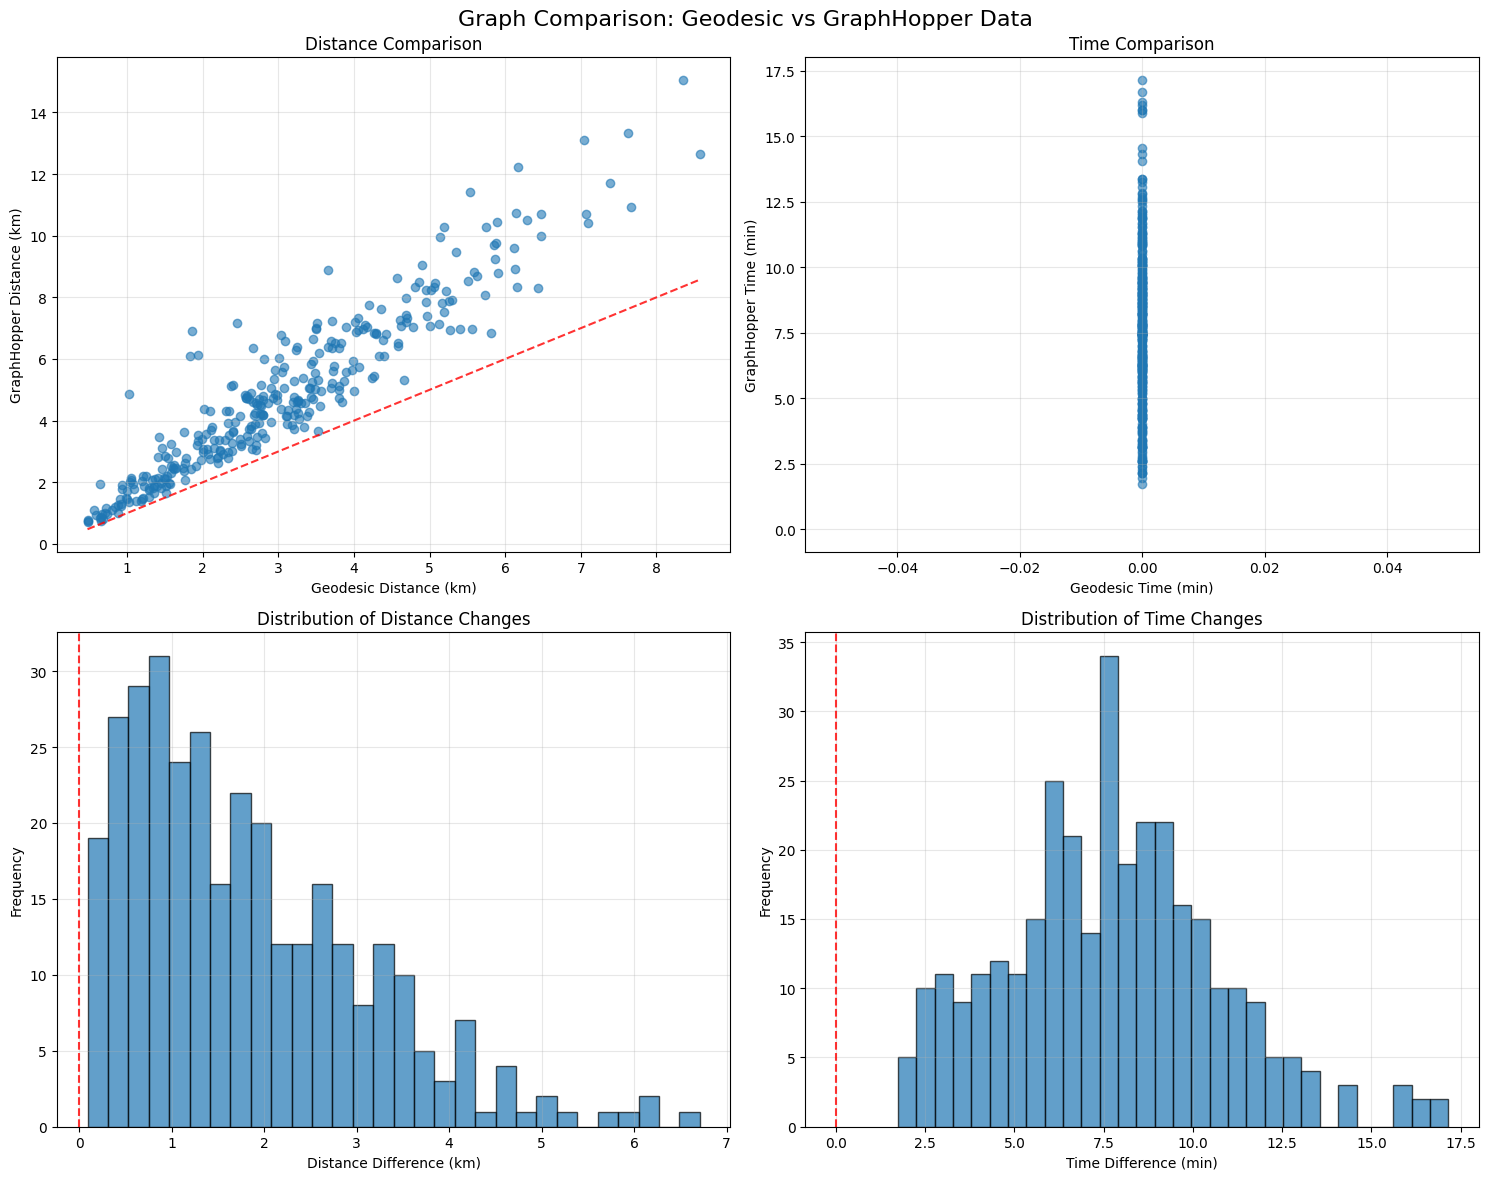


Results saved to 'graph_comparison_results.csv'
1. Full analysis:  {'total_edges': 325, 'distance_stats': {'mean_geodesic': np.float64(3.077815531682808), 'mean_gh': np.float64(4.880907692307693), 'mean_diff': np.float64(1.8030921606248838), 'mean_pct_change': np.float64(59.517473254605505)}, 'time_stats': {'mean_geodesic': np.float64(0.0), 'mean_gh': np.float64(7.717589743589742), 'mean_diff': np.float64(7.717589743589742), 'mean_pct_change': np.float64(0.0)}, 'changes': {'distance_increased': 325, 'distance_decreased': 0, 'time_increased': 325, 'time_decreased': 0}}


In [23]:
print("Graph Comparison Tools Ready!")
print("\nUsage:")
print("1. Full analysis: ", compare_graphs(hotspot_graph, gh_hotspot_graph))
# print("2. Quick summary: ", quick_compare(hotspot_graph, gh_hotspot_graph))

## Break

In [24]:
do it into the next code

SyntaxError: invalid syntax (3220235606.py, line 1)

# Create UMST

In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools

In [ ]:
no_of_mst = 10  # Total no of mst  to finally create UMST
perc_of_egde_drop_in_mst = 0.1 # Everytime 10% edges will drop randomely

## UMST calculation functions

In [ ]:
def calculate_umst(G, num_iterations=100, drop_percentage=0.1, random_seed=None):
    """
    Calculate Union of Multiple Spanning Trees (UMST)

    Parameters:
    - G: NetworkX graph
    - num_iterations: Number of MSTs to generate (default 100)
    - drop_percentage: Percentage of edges to drop each iteration (default 0.1 = 10%)
    - random_seed: Random seed for reproducibility

    Returns:
    - umst_graph: Union of all MSTs
    - mst_collection: List of all individual MSTs
    - edge_frequencies: How often each edge appeared in MSTs
    """

    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)

    print(f"Calculating UMST with {num_iterations} iterations...")
    print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Dropping edges with {drop_percentage*100}% of probability")

    if not nx.is_connected(G):
        print("Warning: Graph is not connected. Using largest connected component.")
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        print(f"Using connected component: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    original_edges = list(G.edges())
    # num_edges_to_drop = int(len(original_edges) * drop_percentage)

    # print(f"Will drop {num_edges_to_drop} edges per iteration")

    mst_collection = []
    edge_frequencies = defaultdict(int)
    successful_iterations = 0

    for iteration in range(num_iterations):
        # Create a copy of the original graph
        G_modified = G.copy()

        # # Randomly drop edges
        # edges_to_drop = random.sample(original_edges, num_edges_to_drop)
        # G_modified.remove_edges_from(edges_to_drop)

        # Randomly drop edges using probabilistic road closure
        edges_to_drop = [edge for edge in original_edges if random.random() < drop_percentage]
        print(f"Iteration {iteration+1}: Dropping {len(edges_to_drop)} edges")

        G_modified.remove_edges_from(edges_to_drop)

        # Check if graph is still connected after dropping edges
        if nx.is_connected(G_modified):
            # Calculate MST of the modified graph
            mst = nx.minimum_spanning_tree(G_modified, weight='weight')
            mst_collection.append(mst)

            # Count edge frequencies
            for edge in mst.edges():
                # Ensure consistent edge representation (smaller node first)
                edge_key = tuple(sorted(edge))
                edge_frequencies[edge_key] += 1

            successful_iterations += 1

            if (iteration + 1) % 20 == 0:
                print(f"Completed {iteration + 1}/{num_iterations} iterations...")
        else:
            if iteration < 10:  # Only print warnings for first few failures
                print(f"Iteration {iteration + 1}: Graph disconnected after dropping edges, skipping...")

    print(f"Successfully completed {successful_iterations}/{num_iterations} iterations")

    if successful_iterations == 0:
        print("Error: No successful iterations! Try reducing drop_percentage.")
        return None, [], {}

    # Create UMST by taking union of all MST edges
    umst_graph = G.copy()
    umst_graph.remove_edges_from(list(umst_graph.edges()))  # Remove all edges first

    # Add all edges that appeared in any MST
    umst_edges = set()
    for mst in mst_collection:
        for edge in mst.edges():
            edge_key = tuple(sorted(edge))
            umst_edges.add(edge_key)

    # Add edges back to UMST graph with original attributes
    for edge_key in umst_edges:
        node1, node2 = edge_key
        if G.has_edge(node1, node2):
            # Copy edge with all original attributes
            edge_data = G[node1][node2].copy()
            umst_graph.add_edge(node1, node2, **edge_data)

            # Add frequency information
            frequency = edge_frequencies[edge_key]
            umst_graph[node1][node2]['mst_frequency'] = frequency
            umst_graph[node1][node2]['frequency_ratio'] = frequency / successful_iterations

    print(f"UMST created: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")
    print(f"Edge reduction: {G.number_of_edges()} → {umst_graph.number_of_edges()} ({(1-umst_graph.number_of_edges()/G.number_of_edges())*100:.1f}% reduction)")

    return umst_graph, mst_collection, dict(edge_frequencies)

## Analyze and visualize UMST edges

In [ ]:
def analyze_umst_results(G_original, umst_graph, edge_frequencies, mst_collection):
    """
    Analyze UMST results and provide statistics
    """
    print("\n" + "="*60)
    print("UMST ANALYSIS")
    print("="*60)

    total_iterations = len(mst_collection)

    print(f"Original graph edges: {G_original.number_of_edges()}")
    print(f"UMST edges: {umst_graph.number_of_edges()}")
    print(f"Edge retention rate: {umst_graph.number_of_edges()/G_original.number_of_edges()*100:.1f}%")

    # Analyze edge frequencies
    frequencies = list(edge_frequencies.values())
    print(f"\nEdge Frequency Statistics:")
    print(f"  Mean frequency: {np.mean(frequencies):.2f}")
    print(f"  Median frequency: {np.median(frequencies):.2f}")
    print(f"  Min frequency: {np.min(frequencies)}")
    print(f"  Max frequency: {np.max(frequencies)}")
    print(f"  Std deviation: {np.std(frequencies):.2f}")

    # Categorize edges by frequency
    high_freq_edges = sum(1 for f in frequencies if f >= total_iterations * 0.8)
    medium_freq_edges = sum(1 for f in frequencies if total_iterations * 0.4 <= f < total_iterations * 0.8)
    low_freq_edges = sum(1 for f in frequencies if f < total_iterations * 0.4)

    print(f"\nEdge Categories:")
    print(f"  High frequency (≥80%): {high_freq_edges} edges")
    print(f"  Medium frequency (40-80%): {medium_freq_edges} edges")
    print(f"  Low frequency (<40%): {low_freq_edges} edges")

    # Analyze MST sizes
    mst_sizes = [mst.number_of_edges() for mst in mst_collection]
    print(f"\nMST Size Statistics:")
    print(f"  Expected MST size (n-1): {umst_graph.number_of_nodes()-1}")
    print(f"  Mean MST size: {np.mean(mst_sizes):.2f}")
    print(f"  MST size range: {np.min(mst_sizes)} - {np.max(mst_sizes)}")

def visualize_umst_comparison(G_original, umst_graph, hotspot_locations, census_df=None):
    """
    Visualize original graph vs UMST side by side
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Plot original graph
    if census_df is not None:
        census_df.plot(ax=ax1, color="white", edgecolor="gray", linewidth=0.5, alpha=0.8)
        census_df.plot(ax=ax2, color="white", edgecolor="gray", linewidth=0.5, alpha=0.8)

    # Plot hotspots
    hotspot_locations.plot(ax=ax1, marker='x', color='black', markersize=30, alpha=0.9)
    hotspot_locations.plot(ax=ax2, marker='x', color='black', markersize=30, alpha=0.9)

    # Plot edges - Original graph
    for edge in G_original.edges():
        node1, node2 = edge
        if node1 in [node for node in G_original.nodes()] and node2 in [node for node in G_original.nodes()]:
            lat1, lon1 = G_original.nodes[node1]['coordinates']
            lat2, lon2 = G_original.nodes[node2]['coordinates']
            ax1.plot([lon1, lon2], [lat1, lat2], 'b-', alpha=0.5, linewidth=0.5)

    # Plot edges - UMST with frequency-based coloring
    for edge in umst_graph.edges(data=True):
        node1, node2, data = edge
        lat1, lon1 = umst_graph.nodes[node1]['coordinates']
        lat2, lon2 = umst_graph.nodes[node2]['coordinates']

        # Color based on frequency
        frequency_ratio = data.get('frequency_ratio', 0)
        if frequency_ratio >= 0.8:
            color, alpha, width = 'red', 0.8, 2.0    # High frequency - thick red
        elif frequency_ratio >= 0.4:
            color, alpha, width = 'orange', 0.6, 1.5  # Medium frequency - orange
        else:
            color, alpha, width = 'blue', 0.4, 1.0    # Low frequency - thin blue

        ax2.plot([lon1, lon2], [lat1, lat2], color=color, alpha=alpha, linewidth=width)

    ax1.set_title(f'Original Graph\n{G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges')
    ax2.set_title(f'UMST Graph\n{umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges')

    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')

    # Add legend for UMST
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, alpha=0.8, label='High frequency (≥80%)'),
        Line2D([0], [0], color='orange', lw=1.5, alpha=0.6, label='Medium frequency (40-80%)'),
        Line2D([0], [0], color='blue', lw=1, alpha=0.4, label='Low frequency (<40%)')
    ]
    ax2.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

def get_critical_edges(umst_graph, threshold=0.8):
    """
    Get edges that appear in most MSTs (critical for connectivity)
    """
    critical_edges = []

    for edge in umst_graph.edges(data=True):
        node1, node2, data = edge
        frequency_ratio = data.get('frequency_ratio', 0)

        if frequency_ratio >= threshold:
            critical_edges.append({
                'edge': (node1, node2),
                'frequency_ratio': frequency_ratio,
                'frequency_count': data.get('mst_frequency', 0),
                'weight': data.get('weight', 0)
            })

    # Sort by frequency ratio
    critical_edges.sort(key=lambda x: x['frequency_ratio'], reverse=True)

    print(f"\nCritical Edges (appearing in ≥{threshold*100}% of MSTs):")
    print(f"Found {len(critical_edges)} critical edges")

    for i, edge_info in enumerate(critical_edges[:10]):  # Show top 10
        edge = edge_info['edge']
        freq_ratio = edge_info['frequency_ratio']
        weight = edge_info['weight']
        print(f"  {i+1:2d}. {edge[0]} ↔ {edge[1]}: {freq_ratio*100:5.1f}% (weight: {weight:.2f})")

    return critical_edges

def visualize_individual_msts(mst_collection, hotspot_locations, census_df=None, max_display=20, msts_per_row=4):
    """
    Visualize individual MSTs to see the variation using a grid layout
    """
    num_msts = min(len(mst_collection), max_display)

    if num_msts == 0:
        print("No MSTs to display")
        return

    # Calculate grid dimensions
    cols = min(msts_per_row, num_msts)
    rows = (num_msts + cols - 1) // cols  # Ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

    # Handle different subplot configurations
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten()
    elif cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # Color palette for different MSTs
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan',
              'magenta', 'yellow', 'navy', 'lime', 'maroon', 'teal', 'silver', 'indigo', 'coral', 'gold']

    for i in range(rows * cols):
        ax = axes[i]

        if i < num_msts:
            mst = mst_collection[i]

            # Plot census tract boundaries
            if census_df is not None:
                census_df.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.3, alpha=0.8)

            # Plot hotspots
            hotspot_locations.plot(ax=ax, marker='o', color='black', markersize=15, alpha=0.9)

            # Plot MST edges
            for edge in mst.edges():
                node1, node2 = edge
                lat1, lon1 = mst.nodes[node1]['coordinates']
                lat2, lon2 = mst.nodes[node2]['coordinates']
                ax.plot([lon1, lon2], [lat1, lat2], color=colors[i % len(colors)],
                       alpha=0.8, linewidth=1.5)

            # Calculate total weight
            total_weight = sum(mst[u][v]['weight'] for u, v in mst.edges())

            ax.set_title(f'MST {i+1}\n{mst.number_of_edges()} edges\nWeight: {total_weight:.1f}km', fontsize=10)
            ax.set_xlabel('Longitude', fontsize=8)
            ax.set_ylabel('Latitude', fontsize=8)
            ax.tick_params(labelsize=8)
        else:
            # Hide unused subplots
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    if num_msts > max_display:
        print(f"Showing first {max_display} MSTs out of {len(mst_collection)} total MSTs")


def compare_mst_statistics(mst_collection):
    """
    Compare statistics across different MSTs
    """
    print("\n" + "="*50)
    print("INDIVIDUAL MST COMPARISON")
    print("="*50)

    for i, mst in enumerate(mst_collection):
        weights = [mst[u][v]['weight'] for u, v in mst.edges()]
        total_weight = sum(weights)

        print(f"MST {i+1}:")
        print(f"  Edges: {mst.number_of_edges()}")
        print(f"  Total weight: {total_weight:.2f} km")
        print(f"  Average edge weight: {np.mean(weights):.2f} km")
        print(f"  Min edge weight: {np.min(weights):.2f} km")
        print(f"  Max edge weight: {np.max(weights):.2f} km")
        print()

def analyze_edge_differences(mst_collection):
    """
    Analyze which edges differ between MSTs
    """
    print("\n" + "="*50)
    print("EDGE DIFFERENCE ANALYSIS")
    print("="*50)

    if len(mst_collection) < 2:
        print("Need at least 2 MSTs for comparison")
        return

    # Get all edges from each MST
    mst_edges = []
    for i, mst in enumerate(mst_collection):
        edges = set()
        for edge in mst.edges():
            edges.add(tuple(sorted(edge)))  # Normalize edge representation
        mst_edges.append(edges)
        print(f"MST {i+1} has {len(edges)} edges")

    # Find common and unique edges
    all_edges = set().union(*mst_edges)
    common_edges = set.intersection(*mst_edges)

    print(f"\nTotal unique edges across all MSTs: {len(all_edges)}")
    print(f"Common edges in all MSTs: {len(common_edges)}")
    print(f"Variable edges: {len(all_edges) - len(common_edges)}")

    # Show which edges are common
    if len(common_edges) > 0:
        print(f"\nEdges that appear in ALL {len(mst_collection)} MSTs:")
        for i, edge in enumerate(sorted(common_edges)[:10]):  # Show first 10
            print(f"  {i+1}. {edge[0]} ↔ {edge[1]}")
        if len(common_edges) > 10:
            print(f"  ... and {len(common_edges) - 10} more")

    # Show which edges vary
    variable_edges = all_edges - common_edges
    if len(variable_edges) > 0:
        print(f"\nEdges that vary between MSTs:")
        for i, edge in enumerate(sorted(variable_edges)[:10]):  # Show first 10
            count = sum(1 for mst_edge_set in mst_edges if edge in mst_edge_set)
            print(f"  {i+1}. {edge[0]} ↔ {edge[1]} (appears in {count}/{len(mst_collection)} MSTs)")
        if len(variable_edges) > 10:
            print(f"  ... and {len(variable_edges) - 10} more")

## UMST Function Call

In [ ]:
# Example usage with your hotspot_graph:
print("Running UMST analysis on your hotspot graph...")
print("Starting with MSTs for initial analysis...")

# Calculate UMST with  iterations first
umst_graph, mst_collection, edge_frequencies = calculate_umst(
    gh_hotspot_graph,  # Use your hotspot graph
    num_iterations= no_of_mst, # Initially taking 40 mst's
    drop_percentage = perc_of_egde_drop_in_mst,  # 0.1 for 10%
    random_seed=42
)

if umst_graph is not None:
    # Show individual MSTs first
    print("\nVisualizing individual MSTs...")
    visualize_individual_msts(mst_collection, hotspot_locations, census_df, max_display=no_of_mst)

    # Compare MST statistics
    compare_mst_statistics(mst_collection)

    # Analyze edge differences
    analyze_edge_differences(mst_collection)

    # Analyze results
    analyze_umst_results(gh_hotspot_graph, umst_graph, edge_frequencies, mst_collection)

    # Get critical edges
    critical_edges = get_critical_edges(umst_graph, threshold=0.6)  # Lower threshold for 5 MSTs

    # Visualize comparison
    print("\nCreating UMST comparison visualization...")
    visualize_umst_comparison(gh_hotspot_graph, umst_graph, hotspot_locations, census_df)

    # Option to run with more MSTs
    print("\n" + "="*60)
    print("All-MST ANALYSIS COMPLETE!")
    print("="*60)
    print("This was just a quick analysis with all MSTs.")
    print("For more robust results, consider running with 50-100 MSTs.")
    print("\nTo run with more MSTs, execute:")
    print("umst_graph_full, mst_collection_full, edge_frequencies_full = calculate_umst(")
    print("    hotspot_graph, num_iterations=100, drop_percentage=0.1, random_seed=42)")

    # Save results
    print("\nSaving all-MST results...")

    umst_clean = prepare_graph_for_graphml(umst_graph)
    nx.write_graphml(umst_clean, umst_dir + "/umst_graph.graphml")
    print(f"UMST saved to: {umst_dir}/umst_graph.graphml")

    # Save MST graph
    mst_graph = nx.minimum_spanning_tree(gh_hotspot_graph, weight="distance")
    mst_graph_clean = prepare_graph_for_graphml(mst_graph)
    nx.write_graphml(mst_graph_clean, umst_dir + "/mst_graph.graphml")
    print(f"MST graph saved to: {umst_dir}/mst_graph.graphml")
    # # Save individual MSTs for analysis
    # for i, mst in enumerate(mst_collection):
    #     mst_clean = prepare_graph_for_graphml(mst)
    #     nx.write_graphml(mst_clean, data_dir + f"/UMST Graph/mst_{i+1}.graphml")



else:
    print("UMST calculation failed. Try reducing the drop_percentage parameter or check graph connectivity.")

In [ ]:
print(f"{dist_threshold}")